In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

def extract_patches_tf(energy, stress, patch_size=18, stride=9):
    """
    energy: tf.Tensor, shape [H, W, n_impacts]
    stress: tf.Tensor, shape [H, W]
    Returns:
      patches: tf.RaggedTensor [num_patches, (n_i), patch_size, patch_size]
      labels:  tf.Tensor        [num_patches]
    """
    H, W, n_impacts = energy.shape
    ph = pw = patch_size
    half = ph // 2

    # 1) Find each impact's (x,y) by argmax of its deposition frame
    flat = tf.reshape(energy, [H*W, n_impacts])                   # [H*W, n_impacts]
    flat_idx = tf.argmax(flat, axis=0, output_type=tf.int32)     # [n_impacts]
    impact_x = flat_idx // W
    impact_y = flat_idx % W
    impact_xy = tf.stack([impact_x, impact_y], axis=1)           # [n_impacts,2]

    # 2) Unstack frames for easy indexing
    frames = tf.unstack(energy, axis=2)                          # list of length n_impacts, each [H,W]

    centers_x = list(range(half, H-half+1, stride))
    centers_y = list(range(half, W-half+1, stride))

    all_patches = []
    all_labels  = []

    for cx in centers_x:
        for cy in centers_y:
            all_labels.append(stress[cx, cy])

            # find indices of impacts inside this patch box
            dx = impact_xy[:,0] - cx
            dy = impact_xy[:,1] - cy
            inside = tf.logical_and(tf.abs(dx) < half,
                                    tf.abs(dy) < half)
            idxs = tf.boolean_mask(tf.range(n_impacts), inside)

            # extract that patch from each kept frame
            local = []
            for i in idxs:
                frame = frames[i]  # [H,W]
                patch = frame[cx-half:cx+half, cy-half:cy+half]  # [18,18]
                local.append(patch)
            if local:
                all_patches.append(tf.stack(local, axis=0))     # [n_i,18,18]
            else:
                all_patches.append(tf.zeros([0,ph,pw], dtype=energy.dtype))

    patches = tf.ragged.stack(all_patches, axis=0)  # [num_patches, None,18,18]
    labels  = tf.stack(all_labels, axis=0)          # [num_patches]
    return patches, labels


In [2]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm

# ---------- helpers ----------

def _looks_headered(first_line: str) -> bool:
    return any(tok in first_line for tok in ("Node", "X", "Y", "Z", "S11", "S22"))

def _grid_from_abaqus_nodes(df, component="avg", decimals=6, atol=1e-12):
    """
    Convert ABAQUS-style node table (Node,X,Y,Z,S11,S22,...) to a 2D grid at min|Z|.
    component ∈ {"S11","S22","avg"}; "avg" = 0.5*(S11+S22).
    Returns ndarray with rows=sorted unique Y, cols=sorted unique X.
    """
    # ensure numeric
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="ignore")

    # surface slice: rows with min |Z|
    zabs = df["Z"].abs()
    df = df[np.isclose(zabs, zabs.min(), atol=atol)].copy()

    # choose value
    if component == "avg":
        if not {"S11", "S22"}.issubset(df.columns):
            raise ValueError("CSV missing S11/S22 for avg computation")
        df["_val"] = 0.5 * (df["S11"] + df["S22"])
    else:
        if component not in df.columns:
            raise ValueError(f"CSV missing required column {component}")
        df["_val"] = df[component]

    # bin XY to handle float jitter
    df["_Xr"] = df["X"].round(decimals)
    df["_Yr"] = df["Y"].round(decimals)

    # average duplicates per bin
    df_agg = df.groupby(["_Yr", "_Xr"], as_index=False)["_val"].mean()

    # pivot to grid
    grid = df_agg.pivot(index="_Yr", columns="_Xr", values="_val")
    grid = grid.sort_index(axis=0).sort_index(axis=1)

    # sanity check
    if grid.isna().any().any():
        nmiss = int(grid.isna().sum().sum())
        raise ValueError(f"Surface grid contains {nmiss} NaNs after pivot. "
                         f"Try adjusting 'decimals' or verify rectilinear XY nodes.")

    return grid.to_numpy()

def _load_surface_from_path(csv_path, component="avg"):
    """
    Load stress map from either:
      - headerless grid CSV -> ndarray
      - ABAQUS node CSV -> build grid at min|Z|, ndarray
    """
    with open(csv_path, "r", encoding="utf-8") as f:
        first = f.readline().strip()

    if _looks_headered(first):
        df = pd.read_csv(csv_path)
        return _grid_from_abaqus_nodes(df, component=component)
    else:
        return pd.read_csv(csv_path, header=None).values

def _find_stress_source(stress_dir, base_name):
    """
    Prefer new naming: <base>_coords_S11_S22.(csv|txt|dat)
    Fallback:          <base>_surfstress.csv
    Returns (path, tag) where tag ∈ {'coords','grid','missing'}
    """
    # new convention
    for ext in ("csv", "txt", "dat"):
        cand = os.path.join(stress_dir, f"{base_name}_coords_S11_S22.{ext}")
        if os.path.exists(cand):
            return cand, "coords"

    # legacy pre-gridded
    old = os.path.join(stress_dir, f"{base_name}_surfstress.csv")
    if os.path.exists(old):
        return old, "grid"

    return None, "missing"

# ---------- main loader ----------

def load_energy_and_stress(energy_dir,
                           stress_dir,
                           component="avg",
                           save_converted=True,
                           write_dir=None):
    """
    Loads energy stacks from energy_dir and builds surface stress maps from stress_dir.
      Energy files:           <base>_energystack.npy  (H0 x W0 x N); we transpose to (H x W x N)
      Stress source priority: <base>_coords_S11_S22.* (ABAQUS nodes @ min|Z| -> grid)
                              <base>_surfstress.csv  (legacy headerless grid)
    component: 'S11', 'S22', or 'avg' (0.5*(S11+S22))
    save_converted: if True and source was 'coords', writes clean grid CSV as <base>_surfstress.csv
    write_dir: directory to write converted grids (default: stress_dir)
    """
    if write_dir is None:
        write_dir = stress_dir

    energy_stacks, stress_maps, labels = [], [], []

    npy_files = sorted(glob(os.path.join(energy_dir, "*_energystack.npy")))
    for npy_path in tqdm(npy_files):
        base_name = os.path.basename(npy_path).replace("_energystack.npy", "")
        stress_path, tag = _find_stress_source(stress_dir, base_name)

        if tag == "missing":
            print(f"⚠️ No stress file for {base_name} (looked for *_coords_S11_S22.* or *_surfstress.csv in {stress_dir})")
            continue

        # energy: transpose to match FEM orientation
        energy = np.load(npy_path).transpose(1, 0, 2)   # -> (H, W, N)

        # stress: load grid (from coords or existing grid)
        stress = _load_surface_from_path(stress_path, component=component)

        # optionally persist converted grid
        if save_converted and tag == "coords":
            out_path = os.path.join(write_dir, f"{base_name}_surfstress.csv")
            pd.DataFrame(stress).to_csv(out_path, header=False, index=False)

        # shape check
        assert energy.shape[:2] == stress.shape, \
            f"{base_name}: energy {energy.shape[:2]} vs stress {stress.shape} mismatch"

        energy_stacks.append(energy)
        stress_maps.append(stress)
        labels.append(base_name)

    return energy_stacks, stress_maps, labels

# --- usage example ---
energy_dir = "./input_data"
stress_dir = "./input_data"
energy_stacks, stress_maps, sample_names = load_energy_and_stress(
    energy_dir=energy_dir,
    stress_dir=stress_dir,
    component="avg",        # 'S11', 'S22', or 'avg' (=0.5*(S11+S22))
    save_converted=True,    # persist grids as <base>_surfstress.csv
    write_dir=stress_dir    # where to write the grids
)

  0%|          | 0/9 [00:00<?, ?it/s]/var/folders/cx/z8x4gz5x3ds3sgqc8zhckdmr0000gn/T/ipykernel_1550/3150071164.py:20: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
 11%|█         | 1/9 [00:00<00:03,  2.21it/s]/var/folders/cx/z8x4gz5x3ds3sgqc8zhckdmr0000gn/T/ipykernel_1550/3150071164.py:20: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")
 22%|██▏       | 2/9 [00:00<00:03,  2.21it/s]/var/folders/cx/z8x4gz5x3ds3sgqc8zhckdmr0000gn/T/ipykernel_1550/3150071164.py:20: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


reading in data, scaling to fix unit mismatch

In [3]:
for i in range(len(energy_stacks)):

    energy_stacks[i] = energy_stacks[i]*1e13

    stress_maps[i] = stress_maps[i]*1e-3

Generating test and training sets

In [6]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import time

max_impacts = 25
size_in = 36
size_out = 16
offset = (size_in - size_out) // 2  # = 10 for 36→16

def center_crop_16x16(x):
    return x[..., offset:offset+size_out, offset:offset+size_out]

def hw_patches_2d(stress_hw, patch_size=36, stride=1):
    s4 = tf.reshape(stress_hw, [1, tf.shape(stress_hw)[0], tf.shape(stress_hw)[1], 1])
    ks = patch_size
    patches = tf.image.extract_patches(
        images=s4,
        sizes=[1, ks, ks, 1],
        strides=[1, stride, stride, 1],
        rates=[1, 1, 1, 1],
        padding='VALID'
    )
    patches = tf.reshape(patches, [-1, ks, ks])
    return patches

# ------- controls for filtering/normalization -------
KEEP_NEG_FRACTION = 0.25     # keep this fraction of “blank” patches as negatives
ENERGY_THRESH = 1e-12         # threshold for deciding a patch has signal (tweak!)
PER_PATCH_NORM = False        # normalize each patch over time+space to [0,1]

frames_chunks, seq_chunks, label_chunks = [], [], []

t0 = time.time()
for i, (energy_np, stress_np) in enumerate(zip(energy_stacks[:], stress_maps[:]), start=1):
    e = tf.convert_to_tensor(energy_np, tf.float32)  # keep float32!
    s = tf.convert_to_tensor(stress_np, tf.float32)

    # ---- ensure energy is [H,W,T] ----
    if e.shape.rank != 3:
        raise ValueError("Energy tensor must be rank-3.")
    if s.shape.rank != 2:
        raise ValueError("Stress map must be rank-2 [H,W].")

    if e.shape[1] == s.shape[0] and e.shape[2] == s.shape[1]:
        # e is [T,H,W] -> transpose to [H,W,T]
        e_hwt = tf.transpose(e, [1, 2, 0]) if e.shape[0] != s.shape[0] else e
    elif e.shape[0] == s.shape[0] and e.shape[1] == s.shape[1]:
        e_hwt = e  # already [H,W,T]
    else:
        # fallback assume [T,H,W]
        e_hwt = tf.transpose(e, [1, 2, 0])

    # ---- A) energy patches (ragged/dense) ----
    # NOTE: uses your existing function; make sure it extracts 36x36 around sliding centers
    e_rt, _ = extract_patches_tf(e_hwt, s, patch_size=size_in, stride=1)  # returns [K, T_i, 36,36] (ragged) or dense

    # ---- B) stress patches at same positions ----
    s_patches = hw_patches_2d(s, patch_size=size_in, stride=1)            # [K,36,36]

    # ---- time pad/truncate to max_impacts ----
    if isinstance(e_rt, tf.RaggedTensor):
        e_dense = e_rt.to_tensor(shape=[None, max_impacts, size_in, size_in], default_value=0.0)
        # simple heuristic for seq_len: any nonzero in each time step
        seq_len = tf.minimum(
            tf.reduce_sum(tf.cast(tf.reduce_any(tf.not_equal(e_dense, 0.0), axis=[2,3]), tf.int32), axis=1),
            max_impacts
        )
    else:
        tdim = tf.shape(e_rt)[1]
        pad_t = tf.maximum(0, max_impacts - tdim)
        e_dense = tf.pad(e_rt, [[0,0],[0,pad_t],[0,0],[0,0]])[:, :max_impacts]
        seq_len = tf.minimum(
            tf.reduce_sum(tf.cast(tf.reduce_any(tf.not_equal(e_dense, 0.0), axis=[2,3]), tf.int32), axis=1),
            max_impacts
        )

    # ---- OPTIONAL: per-patch normalization to [0,1] to avoid scale issues/underflow ----
    if PER_PATCH_NORM:
        # normalize over time+H+W per patch
        B = tf.shape(e_dense)[0]
        flat = tf.reshape(e_dense, [B, -1])
        mn = tf.reduce_min(flat, axis=1, keepdims=True)
        mx = tf.reduce_max(flat, axis=1, keepdims=True)
        denom = tf.maximum(mx - mn, 1e-12)
        norm = (flat - mn) / denom
        e_dense = tf.reshape(norm, tf.shape(e_dense))

    # ---- FILTER: keep any patch with non-zero total energy ----
    # If your energy can be signed, use abs(); otherwise plain sum is fine.
    patch_energy = tf.reduce_sum(tf.abs(e_dense), axis=[1, 2, 3])   # [K]
    keep_idx = tf.where(patch_energy > 0.0)[:, 0]                   # indices to keep

    # Safety: if nothing passes, keep the single most energetic patch
    kK = tf.shape(e_dense)[0]
    def _fallback_keep_one():
        # top-1 by energy
        top1 = tf.argsort(patch_energy, direction="DESCENDING")[:1]
        return top1

    keep_idx = tf.cond(
        tf.equal(tf.size(keep_idx), 0),
        true_fn=_fallback_keep_one,
        false_fn=lambda: keep_idx
    )

    # apply selection
    e_dense   = tf.gather(e_dense, keep_idx)
    s_patches = tf.gather(s_patches, keep_idx)
    seq_len   = tf.gather(seq_len, keep_idx)

    # ---- labels: center crop 16x16 ----
    y16 = center_crop_16x16(s_patches)                    # [K,16,16]
    y16 = tf.expand_dims(y16, -1)                         # [K,16,16,1]

    # ---- add channel & KEEP float32! ----
    frames_np = tf.expand_dims(e_dense, -1).numpy().astype(np.float32)   # (K,T,36,36,1)
    seq_np    = seq_len.numpy().astype(np.int32)                         # (K,)
    labels_np = y16.numpy().astype(np.float32)                           # (K,16,16,1)

    # quick sanity on this batch
    # print(frames_np.min(), frames_np.max(), frames_np.mean(), frames_np.std())

    frames_chunks.append(frames_np)
    seq_chunks.append(seq_np)
    label_chunks.append(labels_np)

    print(f"Processed {i}/{len(energy_stacks[:])} samples in {time.time() - t0:.1f}s "
          f"-> kept {frames_np.shape[0]} patches")

# -----------------------------
# Assemble & split
# -----------------------------
frames_arr = np.concatenate(frames_chunks, axis=0)   # (N,T,36,36,1)
seq_arr    = np.concatenate(seq_chunks, axis=0)      # (N,)
label_arr  = np.concatenate(label_chunks, axis=0)    # (N,16,16,1)

Xf_train, Xf_val, sl_train, sl_val, y_train, y_val = train_test_split(
    frames_arr, seq_arr, label_arr, test_size=0.2, shuffle=True
)

def make_ds(frames, seq, labels, shuffle=True, batch=32):
    ds = tf.data.Dataset.from_tensor_slices(((frames, seq), labels))
    if shuffle:
        ds = ds.shuffle(min(len(frames), 4096), reshuffle_each_iteration=True)
    return ds.batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(Xf_train, sl_train, y_train, shuffle=True,  batch=32)
val_ds   = make_ds(Xf_val,   sl_val,   y_val,   shuffle=False, batch=32)

Processed 1/9 samples in 82.5s -> kept 46629 patches
Processed 2/9 samples in 162.9s -> kept 46235 patches
Processed 3/9 samples in 245.2s -> kept 46401 patches
Processed 4/9 samples in 354.1s -> kept 46656 patches
Processed 5/9 samples in 462.7s -> kept 46656 patches
Processed 6/9 samples in 570.6s -> kept 46656 patches
Processed 7/9 samples in 733.4s -> kept 46656 patches
Processed 8/9 samples in 895.0s -> kept 46656 patches
Processed 9/9 samples in 1058.6s -> kept 46656 patches


In [7]:
print("frames_arr:", frames_arr.shape, frames_arr.dtype)   # expect (N, 25, 36, 36, 1)
print("seq_arr:   ", seq_arr.shape,   seq_arr.dtype)       # expect (N,)
print("label_arr: ", label_arr.shape, label_arr.dtype)     # expect (N, 16, 16, 1)

# sanity check first sample
i = 0
print("\nSample 0:")
print("frames[0] shape:", frames_arr[i].shape)  # (25,36,36,1)
print("seq[0] value:   ", seq_arr[i])
print("label[0] shape: ", label_arr[i].shape)   # (16,16,1)

# min/max to check scaling
print("\nValue ranges:")
print("frames min/max:", frames_arr.min(), frames_arr.max())
print("labels min/max:", label_arr.min(), label_arr.max())

frames_arr: (419201, 25, 36, 36, 1) float32
seq_arr:    (419201,) int32
label_arr:  (419201, 16, 16, 1) float32

Sample 0:
frames[0] shape: (25, 36, 36, 1)
seq[0] value:    4
label[0] shape:  (16, 16, 1)

Value ranges:
frames min/max: 0.0 0.84011906
labels min/max: -9.115136 5.6677003


In [8]:
X_train_np = np.asarray(Xf_train, dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.float32)
X_val_np   = np.asarray(Xf_val,   dtype=np.float32)
y_val_np   = np.asarray(y_val,   dtype=np.float32)

BATCH = 64

def make_ds(X, y, shuffle=False, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(min(len(X), 10000), reshuffle_each_iteration=True)
    ds = ds.batch(batch, drop_remainder=False)  # single batch op
    return ds

train_ds = make_ds(X_train_np, y_train_np, shuffle=True)
val_ds   = make_ds(X_val_np,   y_val_np,   shuffle=False)

loss functions and training monitor definitions

In [11]:
# ---- If smoke test passes, switch to graph mode & full dataset for speed ----
print("\n>>> Switching to graph mode (faster) and full training…")

import tensorflow as tf

def mse_plus_variance(alpha=0.2, reduce_axes=(1,2,3), eps=1e-12):
    """Loss = MSE + alpha * mean(|Var_pred - Var_true|) over the batch."""
    def loss_fn(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_pred - y_true))
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        var_gap = tf.reduce_mean(tf.abs(var_p - var_t))   # per-sample → batch mean
        return mse + alpha * var_gap
    return loss_fn

def var_gap_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean absolute variance gap: E[ |Var(ŷ) - Var(y)| ]."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        return tf.reduce_mean(tf.abs(var_p - var_t))
    _metric.__name__ = "var_gap"
    return _metric

def var_ratio_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean variance ratio: E[ Var(ŷ) / Var(y) ]. 1.0 == perfect."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        ratio = var_p / tf.maximum(var_t, eps)
        return tf.reduce_mean(ratio)
    _metric.__name__ = "var_ratio"
    return _metric

def var_logratio_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean |log-variance ratio|: E[ |log(Var(ŷ)/Var(y))| ]. 0 == perfect."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        logratio = tf.math.log(tf.maximum(var_p, eps)) - tf.math.log(tf.maximum(var_t, eps))
        return tf.reduce_mean(tf.abs(logratio))
    _metric.__name__ = "var_logratio"
    return _metric


>>> Switching to graph mode (faster) and full training…


model definition and training

In [ ]:
# ==== HARD RESET ====
import os, gc, numpy as np, tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import Huber


# Safety: disable XLA/JIT and mixed precision during debug.
try: tf.config.optimizer.set_jit(False)
except Exception: pass
try: tf.keras.mixed_precision.set_global_policy("float32")
except Exception: pass

tf.keras.backend.clear_session(); gc.collect()

# ---- Rebuild clean datasets from your split arrays ----
# Assumes Xf_train, y_train, Xf_val, y_val already exist with shapes:
# X: (N, 25, 36, 36, 1) float32/float16, y: (N, 16, 16, 1) float32
X_train_np = np.asarray(Xf_train, dtype=np.float32)
y_train_np = np.asarray(y_train, dtype=np.float32)
X_val_np   = np.asarray(Xf_val,   dtype=np.float32)
y_val_np   = np.asarray(y_val,   dtype=np.float32)

BATCH = 64

def make_ds(X, y, shuffle=False, batch=BATCH):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(min(len(X), 10000), reshuffle_each_iteration=True)
    ds = ds.batch(batch, drop_remainder=False)  # single batch op
    return ds

train_ds = make_ds(X_train_np, y_train_np, shuffle=True)
val_ds   = make_ds(X_val_np,   y_val_np,   shuffle=False)

print("Specs:", train_ds.element_spec)

# # ---- Model: fast ConvLSTM at 9x9 encoder-decoder ----
T, H, W, C = 25, 36, 36, 1
OUT, CROP = 16, (36 - 16)//2  # 10

def FabricConvLSTM_Fast():
    x_in = Input(shape=(T, H, W, C), name="frames")

    # Per-frame encoder: 36x36 -> 18x18 -> 9x9
    x = layers.TimeDistributed(layers.Conv2D(16, 3, strides=2, padding="same", activation="gelu"))(x_in)  # 18x18
    x = layers.TimeDistributed(layers.Conv2D(32, 3, strides=2, padding="same", activation="gelu"))(x)     # 9x9

    # ConvLSTM @ 9x9
    x = layers.ConvLSTM2D(48, 3, padding="same", return_sequences=True,
                          activation="tanh", recurrent_activation="sigmoid")(x)
    x = layers.ConvLSTM2D(64, 3, padding="same", return_sequences=False,
                          activation="tanh", recurrent_activation="sigmoid")(x)  # (9,9,64)

    # Decoder: 9x9 -> 18x18 -> 16x16
    x = layers.Conv2D(64, 3, padding="same", activation="gelu")(x)        # 9x9
    x = layers.UpSampling2D(2, interpolation="bilinear")(x)               # 18x18
    x = layers.Conv2D(64, 3, padding="same", activation="gelu")(x)        # 18x18
    x = layers.Conv2D(32, 3, padding="same", activation="gelu")(x)        # 18x18
    x = layers.Conv2D(32, 3, padding="valid", activation="gelu")(x)       # 16x16
    y = layers.Conv2D(1, 1, padding="same", activation=None, name="y16")(x)

    m = Model(x_in, y, name="FabricConvLSTM_Fast")
    # Debug compile: eager mode + no JIT to avoid OptionalFromValue quirks
    m.compile(optimizer=tf.keras.optimizers.AdamW(3e-4),
              loss="huber", metrics=["mae"],
              run_eagerly=True,   # <- important for clear Python errors first
              jit_compile=False)  # <- keep off until stable
    return m

model = FabricConvLSTM_Fast()
model.summary()



# ---- Tiny smoke fit (few steps) to verify end-to-end ----
# Take a small slice to ensure the step works
SMALL_STEPS = 3
small_train = train_ds.take(SMALL_STEPS)
small_val   = val_ds.take(1)

ckpt    = ModelCheckpoint("logs_convlstm/best.keras", save_best_only=True, monitor="val_mae", mode="min")
early   = EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True)
plateau = ReduceLROnPlateau(monitor="val_mae", mode="min", factor=0.5, patience=5, cooldown=1, min_delta=0.003)

print("\n>>> Smoke test fit (few steps, eager=True)")
history = model.fit(
    small_train,
    validation_data=small_val,
    epochs=1,
    callbacks=[ckpt],
)

# ---- If smoke test passes, switch to graph mode & full dataset for speed ----
print("\n>>> Switching to graph mode (faster) and full training…")

import tensorflow as tf

def mse_plus_variance(alpha=0.2, reduce_axes=(1,2,3), eps=1e-12):
    """Loss = MSE + alpha * mean(|Var_pred - Var_true|) over the batch."""
    def loss_fn(y_true, y_pred):
        mse = tf.reduce_mean(tf.square(y_pred - y_true))
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        var_gap = tf.reduce_mean(tf.abs(var_p - var_t))   # per-sample → batch mean
        return mse + alpha * var_gap
    return loss_fn

def var_gap_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean absolute variance gap: E[ |Var(ŷ) - Var(y)| ]."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        return tf.reduce_mean(tf.abs(var_p - var_t))
    _metric.__name__ = "var_gap"
    return _metric

def var_ratio_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean variance ratio: E[ Var(ŷ) / Var(y) ]. 1.0 == perfect."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        ratio = var_p / tf.maximum(var_t, eps)
        return tf.reduce_mean(ratio)
    _metric.__name__ = "var_ratio"
    return _metric

def var_logratio_metric(reduce_axes=(1,2,3), eps=1e-12):
    """Mean |log-variance ratio|: E[ |log(Var(ŷ)/Var(y))| ]. 0 == perfect."""
    def _metric(y_true, y_pred):
        var_t = tf.math.reduce_variance(y_true, axis=reduce_axes)
        var_p = tf.math.reduce_variance(y_pred, axis=reduce_axes)
        logratio = tf.math.log(tf.maximum(var_p, eps)) - tf.math.log(tf.maximum(var_t, eps))
        return tf.reduce_mean(tf.abs(logratio))
    _metric.__name__ = "var_logratio"
    return _metric


model.compile(
    optimizer=tf.keras.optimizers.AdamW(6e-4),
    loss=mse_plus_variance(alpha=0.5),   # keep units in GPa^2
    metrics=["mae", "mse",
             var_gap_metric(),
             var_ratio_metric(),         # aim for ~1.0
             var_logratio_metric()]      # aim for ~0.0
)

# (Optionally add prefetch now that pipeline is stable)
train_ds_pf = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds_pf   = val_ds.prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds_pf,
    validation_data=val_ds_pf,
    epochs=60,
    callbacks=[ckpt, early, plateau],
)

Specs: (TensorSpec(shape=(None, 25, 36, 36, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 16, 16, 1), dtype=tf.float32, name=None))


Model: "FabricConvLSTM_Fast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frames (InputLayer)             │ (None, 25, 36, 36, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 25, 18, 18, 16) │           160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 25, 9, 9, 32)   │         4,640 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 25, 9, 9, 48)   │       138,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 9, 9, 64)       │       258,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 9, 9, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 18, 18, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y16 (Conv2D)                    │ (None, 16, 16, 1)      │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 503,137 (1.92 MB)

 Trainable params: 503,137 (1.92 MB)

 Non-trainable params: 0 (0.00 B)


>>> Smoke test fit (few steps, eager=True)
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - loss: 0.4319 - mae: 0.8503 - val_loss: 0.3920 - val_mae: 0.8017

>>> Switching to graph mode (faster) and full training…
Epoch 1/60
5240/5240 ━━━━━━━━━━━━━━━━━━━━ 3216s 611ms/step - loss: 0.2978 - mae: 0.3555 - mse: 0.2247 - var_gap: 0.1461 - var_logratio: 2.1524 - var_ratio: 0.3465 - val_loss: 0.1778 - val_mae: 0.2777 - val_mse: 0.1420 - val_var_gap: 0.0716 - val_var_logratio: 0.4684 - val_var_ratio: 0.7001 - learning_rate: 6.0000e-04
Epoch 2/60
5240/5240 ━━━━━━━━━━━━━━━━━━━━ 3213s 613ms/step - loss: 0.1572 - mae: 0.2665 - mse: 0.1319 - var_gap: 0.0506 - var_logratio: 0.3389 - var_ratio: 0.8203 - val_loss: 0.1274 - val_mae: 0.2360 - val_mse: 0.1050 - val_var_gap: 0.0448 - val_var_logratio: 0.2967 - val_var_ratio: 0.8172 - learning_rate: 6.0000e-04
Epoch 3/60
5240/5240 ━━━━━━━━━━━━━━━━━━━━ 3223s 615ms/step - loss: 0.1196 - mae: 0.2329 - mse: 0.1021 - var_gap: 0.0351 - var_logratio: 0.2360 - var_ratio: 0.

KeyboardInterrupt: 

OPTIONAL: Resume training.

In [ ]:
import tensorflow as tf
import os

BEST_PATH = "logs_convlstm/best.keras"
BEST_PATH_RESUME = "logs_convlstm/best_resume.keras"

# ---- If you saved full model previously ----
if os.path.exists(BEST_PATH):
    model = tf.keras.models.load_model(BEST_PATH, compile=False)
    print(f"✅ Loaded model from: {BEST_PATH}")
else:
    model = FabricConvLSTM_Fast()
    print("ℹ️ No prior checkpoint found; training from scratch.")

# Always recompile with your fixed LR, using MAE as the loss
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4),
    loss="mae",               # <<<<<< here
    metrics=["mse"],          # optional: still track MSE for reporting
    run_eagerly=False,
    jit_compile=False
)

# Callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

ckpt    = ModelCheckpoint(BEST_PATH_RESUME, save_best_only=True, monitor="val_loss", mode="min")
early   = EarlyStopping(monitor="val_loss", mode="min", patience=5, restore_best_weights=True)
plateau = ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.5, patience=5, cooldown=1, min_delta=0.003)

# Training
history = model.fit(
    train_ds.prefetch(tf.data.AUTOTUNE),
    validation_data=val_ds.prefetch(tf.data.AUTOTUNE),
    epochs=60,
    callbacks=[ckpt, early, plateau],
    verbose=1
)

# Final eval
best_model = tf.keras.models.load_model(BEST_PATH_RESUME, compile=True)
print("Final eval:", best_model.evaluate(val_ds, verbose=0))

✅ Loaded model from: logs_convlstm_fast_try4_logcosh/best.keras
Epoch 1/60
 890/5240 ━━━━━━━━━━━━━━━━━━━━ 41:25 571ms/step - loss: 0.1453 - mse: 0.0416

KeyboardInterrupt: 

create parity statistics

2025-10-08 11:04:40.173786: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


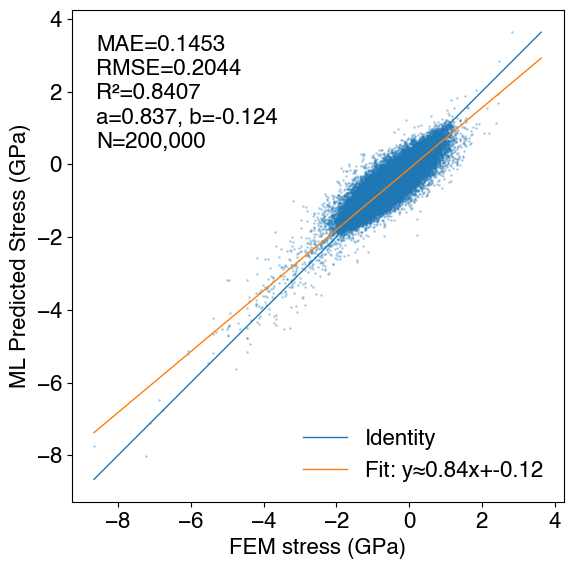

{'MAE': 0.14530125260353088, 'RMSE': 0.2043764442205429, 'R2': 0.8407135131302367, 'a': 0.837308943271637, 'b': -0.12388675659894943, 'N': 200000}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'Helvetica'})

def parity_plot_spatial(model, val_ds, max_points=200_000, title="Validation Parity"):
    """
    Streams over val_ds -> builds a parity plot (true vs predicted per-pixel).
    Uses reservoir sampling so memory stays bounded.
    """
    rng = np.random.default_rng(0)
    yt_buf = np.empty(max_points, dtype=np.float32)
    yp_buf = np.empty(max_points, dtype=np.float32)
    n_seen = 0

    # Stream over validation dataset
    for xb, yb in val_ds:
        # Predict
        ypred = model.predict(xb, verbose=0)  # (B,16,16,1)

        # Flatten batch
        yt = yb.numpy().reshape(-1)
        yp = ypred.reshape(-1)

        # Drop NaN/Inf
        m = np.isfinite(yt) & np.isfinite(yp)
        yt = yt[m]; yp = yp[m]

        # Reservoir sample into fixed-size buffers
        k = yt.size
        if k == 0:
            continue
        if n_seen < max_points:
            # Fill until buffers full
            take = min(max_points - n_seen, k)
            yt_buf[n_seen:n_seen+take] = yt[:take]
            yp_buf[n_seen:n_seen+take] = yp[:take]
            n_seen += take
            # If still overflow beyond, reservoir sample remaining
            start = take
        else:
            start = 0

        # Reservoir replace for remaining points, if any
        for j in range(start, k):
            n_seen += 1
            r = rng.integers(0, n_seen)
            if r < max_points:
                yt_buf[r] = yt[j]
                yp_buf[r] = yp[j]

    # Use the filled portion
    if n_seen == 0:
        print("No finite validation points collected.")
        return None
    n_used = min(n_seen, max_points)
    yt_s = yt_buf[:n_used]
    yp_s = yp_buf[:n_used]

    # Metrics
    mae  = float(np.mean(np.abs(yp_s - yt_s)))
    rmse = float(np.sqrt(np.mean((yp_s - yt_s)**2)))
    ss_res = float(np.sum((yt_s - yp_s)**2))
    ss_tot = float(np.sum((yt_s - yt_s.mean())**2)) + 1e-12
    r2   = 1.0 - ss_res / ss_tot

    # Optional linear calibration fit: yp ≈ a*yt + b
    A = np.vstack([yt_s, np.ones_like(yt_s)]).T
    a, b = np.linalg.lstsq(A, yp_s, rcond=None)[0]

    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(yt_s, yp_s, s=1, alpha=0.25)
    mn = float(np.min([yt_s.min(), yp_s.min()]))
    mx = float(np.max([yt_s.max(), yp_s.max()]))
    plt.plot([mn, mx], [mn, mx], linewidth=1, label="Identity")
    plt.plot([mn, mx], [a*mn + b, a*mx + b], linewidth=1, label=f"Fit: y≈{a:.2f}x+{b:.2f}")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("FEM stress (GPa)")
    plt.ylabel("ML Predicted Stress (GPa)")
    # plt.title(title)
    txt = f"MAE={mae:.4f}\nRMSE={rmse:.4f}\nR²={r2:.4f}\na={a:.3f}, b={b:.3f}\nN={n_used:,}"
    plt.text(0.05, 0.95, txt, transform=plt.gca().transAxes, va="top", ha="left")
    plt.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()

    return yt_s, yp_s, dict(MAE=mae, RMSE=rmse, R2=r2, a=float(a), b=float(b), N=n_used)


# model = tf.keras.models.load_model("logs_convlstm/best.keras", compile=True)

train_ds_pf = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds_pf   = val_ds.prefetch(tf.data.AUTOTUNE)

# ---- run it ----
yt_s, yp_s, stats = parity_plot_spatial(model, val_ds_pf if 'val_ds_pf' in globals() else val_ds,
                            max_points=200_000,
                            title="FabricConvLSTM_Fast — Validation Parity")
print(stats)

generate parity plot.

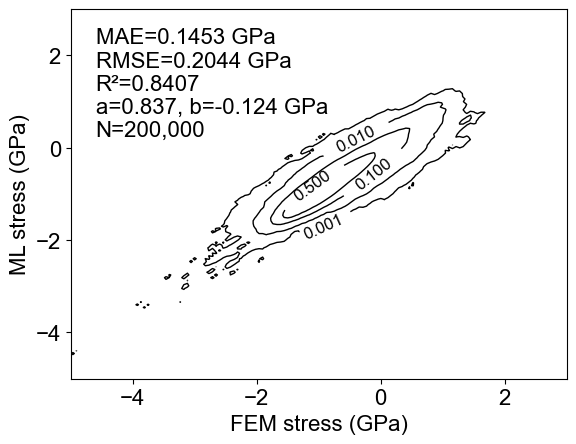

In [141]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'Arial'})  # fallback that always works

# data arrays
x, y = yt_s, yp_s
values = np.vstack([x, y])
kde = gaussian_kde(values)

# grid for evaluation
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

fig, ax = plt.subplots()

# contour plot with explicit levels
levels = [0.001, 0.01, 0.1, 0.5]  # whatever density values you want
cs = ax.contour(X, Y, Z, levels=levels, colors="k", linewidths=1)

# add automatic labels
ax.clabel(cs, inline=True, fontsize=12, fmt="%.3f")


txt = f"MAE={stats['MAE']:.4f} GPa\nRMSE={stats['RMSE']:.4f} GPa \nR²={stats['R2']:.4f}\na={stats['a']:.3f}, b={stats['b']:.3f} GPa \nN={stats['N']:,}"
plt.text(0.05, 0.95, txt, transform=plt.gca().transAxes, va="top", ha="left")


ax.set_xlabel("FEM stress (GPa)")
ax.set_ylabel("ML stress (GPa)")
ax.set_xlim(-5, 3.)
ax.set_ylim(-5, 3.)

plt.xticks([-4, -2, 0, 2])
plt.yticks([-4, -2, 0, 2])

plt.savefig("parity_contours.jpg", dpi=600)

plt.show()

evaluate per-pixel parity statistics

2025-10-08 11:16:33.260594: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


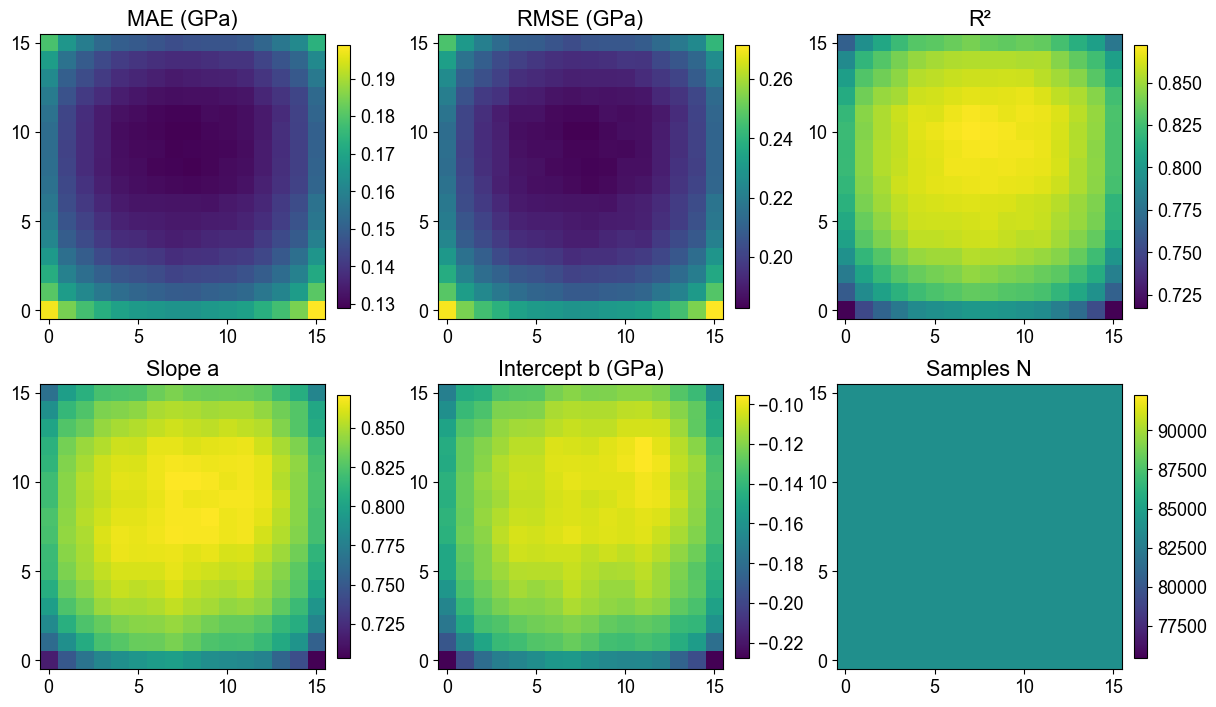

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def per_pixel_parity_stats(model, val_ds, out_h=16, out_w=16, eps=1e-12):
    """
    Streams over val_ds and computes per-pixel stats between FEM (yt) and ML (yp).
    Returns dict of HxW arrays: MAE, RMSE, R2, a, b, N.
    """
    P = out_h * out_w

    # Sufficient statistics per pixel (flattened length P)
    N          = np.zeros(P, dtype=np.int64)
    sum_x      = np.zeros(P, dtype=np.float64)  # true
    sum_y      = np.zeros(P, dtype=np.float64)  # pred
    sum_x2     = np.zeros(P, dtype=np.float64)
    sum_y2     = np.zeros(P, dtype=np.float64)
    sum_xy     = np.zeros(P, dtype=np.float64)
    sum_abserr = np.zeros(P, dtype=np.float64)
    sum_sqe    = np.zeros(P, dtype=np.float64)

    for xb, yb in val_ds:
        yp = model.predict(xb, verbose=0)             # (B,H,W,1)
        xt = yb.numpy()                                # (B,H,W,1)

        # flatten batch to (B, P)
        X = xt.reshape(xt.shape[0], -1)
        Y = yp.reshape(yp.shape[0], -1)

        # finite mask
        M = np.isfinite(X) & np.isfinite(Y)
        if not np.any(M):
            continue

        # zero out non-finite and accumulate counts
        Xz, Yz = np.where(M, X, 0.0), np.where(M, Y, 0.0)
        n = M.sum(axis=0)

        N          += n
        sum_x      += Xz.sum(axis=0)
        sum_y      += Yz.sum(axis=0)
        sum_x2     += (Xz * Xz).sum(axis=0)
        sum_y2     += (Yz * Yz).sum(axis=0)
        sum_xy     += (Xz * Yz).sum(axis=0)
        diff        = (Yz - Xz)
        sum_abserr += np.abs(diff).sum(axis=0)
        sum_sqe    += (diff * diff).sum(axis=0)

    # avoid divide-by-zero
    Nz = np.maximum(N, 1)

    mae  = (sum_abserr / Nz).reshape(out_h, out_w)
    rmse = np.sqrt(sum_sqe / Nz).reshape(out_h, out_w)

    # linear fit y ~ a x + b
    denom = (Nz * sum_x2 - sum_x**2) + eps
    a = (Nz * sum_xy - sum_x * sum_y) / denom
    b = (sum_y - a * sum_x) / Nz

    # R^2 using SS_res and SS_tot
    ss_res = sum_sqe
    ss_tot = (sum_x2 - (sum_x**2) / Nz)
    r2 = 1.0 - ss_res / (ss_tot + eps)

    stats = {
        "MAE":  mae,
        "RMSE": rmse,
        "R2":   r2.reshape(out_h, out_w),
        "a":    a.reshape(out_h, out_w),
        "b":    b.reshape(out_h, out_w),
        "N":    N.reshape(out_h, out_w),
    }
    return stats

def plot_per_pixel_stats(stats, unit="GPa"):
    """Quick 2×3 panel of MAE, RMSE, R², slope a, intercept b, and N."""
    fig, axs = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    keys = [("MAE", f"MAE ({unit})"),
            ("RMSE", f"RMSE ({unit})"),
            ("R2", "R²"),
            ("a", "Slope a"),
            ("b", f"Intercept b ({unit})"),
            ("N", "Samples N")]

    for ax, (k, title) in zip(axs.ravel(), keys):
        im = ax.imshow(stats[k], origin="lower", aspect="equal")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks([0, 5, 10, 15]); ax.set_yticks([0, 5, 10, 15])
    plt.show()

# ---- run it ----
stats_map = per_pixel_parity_stats(
    model,
    val_ds_pf if 'val_ds_pf' in globals() else val_ds,
    out_h=16, out_w=16
)
plot_per_pixel_stats(stats_map)

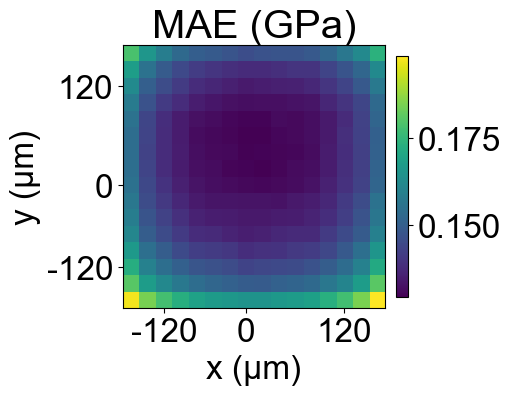

In [140]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'font.size': 24})

def plot_mae_r2(stats, unit="GPa", patch_size_um=320, out_h=16, out_w=16):
    fig, axs = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)

    # coordinate ticks in microns
    x_ticks = np.linspace(2, out_w-3, 3, dtype=int)  
    y_ticks = np.linspace(2, out_h-3, 3, dtype=int)
    x_labels = np.linspace(-120, 120, 3, dtype=int)  # microns
    y_labels = np.linspace(-120, 120, 3, dtype=int)

    # --- MAE ---
    im0 = axs.imshow(stats["MAE"], origin="lower", aspect="equal", cmap="viridis")
    axs.set_title(f"MAE ({unit})")
    axs.set_xticks(x_ticks); axs.set_xticklabels(x_labels)
    axs.set_yticks(y_ticks); axs.set_yticklabels(y_labels)
    axs.set_xlabel("x (µm)"); axs.set_ylabel("y (µm)")
    plt.colorbar(im0, ax=axs, fraction=0.046, pad=0.04)

    # --- R² ---
    # im1 = axs[1].imshow(stats["R2"], origin="lower", aspect="equal", cmap="viridis")
    # axs[1].set_title("R²")
    # axs[1].set_xticks(x_ticks); axs[1].set_xticklabels(x_labels)
    # axs[1].set_yticks(y_ticks); axs[1].set_yticklabels(y_labels)
    # axs[1].set_xlabel("x (µm)"); axs[1].set_ylabel("y (µm)")
    # plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    # fig.suptitle("Per-pixel error and fit quality across patch (320×320 µm²)", y=0.98)
    # plt.savefig("per_pixel_mae_r2.jpg", dpi=600)
    plt.show()
    
plot_mae_r2(stats_map, unit="GPa")


function to predict continuous field.

In [42]:
def predict_full_field_center_sparse_allN(
    model, energy_stack, tile_in=36, tile_out=16,
    center_size=4, stride=4,
    energy_thresh=0.0, keep_one_if_empty=True,
    per_patch_norm=False, batch_size=256, pad_mode="reflect"
):
    H, W, N = energy_stack.shape
    T = int(model.input_shape[1])
    halo = (tile_in - tile_out)//2
    off  = (tile_out - center_size)//2

    # (N,H,W,1) + spatial pad
    frames_all = energy_stack.transpose(2,0,1)[...,None].astype(np.float32)
    frames_pad = np.pad(frames_all, ((0,0),(halo,halo),(halo,halo),(0,0)), mode=pad_mode)

    def _grid_out(L, block, step):
        pos = list(range(0, max(L - block, 0) + 1, step))
        if not pos or pos[-1] != L - block:
            pos.append(max(L - block, 0))
        return pos

    ys_out = _grid_out(H, center_size, stride)
    xs_out = _grid_out(W, center_size, stride)
    B = len(ys_out)*len(xs_out)

    crops = np.zeros((B, T, tile_in, tile_in, 1), np.float32)
    paste_coords = []
    b = 0
    for y_out in ys_out:
        for x_out in xs_out:
            # 16×16 valid start implied by desired center block
            y_valid0 = int(np.clip(y_out - off, 0, H - tile_out))
            x_valid0 = int(np.clip(x_out - off, 0, W - tile_out))

            # input crop on *padded* tensor starts at valid start (halo already added)
            y_in0, x_in0 = y_valid0, x_valid0
            slab = frames_pad[:, y_in0:y_in0+tile_in, x_in0:x_in0+tile_in, :]
            if slab.shape[1] != tile_in or slab.shape[2] != tile_in:
                dy = tile_in - slab.shape[1]; dx = tile_in - slab.shape[2]
                slab = np.pad(slab, ((0,0),(0,max(0,dy)),(0,max(0,dx)),(0,0)), mode=pad_mode)
                slab = slab[:, :tile_in, :tile_in, :]

            # time filtering (like training)
            e_t = np.sum(np.abs(slab), axis=(1,2,3))
            idx = np.flatnonzero(e_t > energy_thresh)
            if idx.size == 0 and keep_one_if_empty:
                idx = np.array([int(np.argmax(e_t))], dtype=int)

            seq = slab[idx]
            if per_patch_norm and seq.size:
                flat = seq.reshape(1,-1); mn = flat.min(axis=1, keepdims=True)
                mx = flat.max(axis=1, keepdims=True); den = np.maximum(mx-mn,1e-12)
                seq = ((flat-mn)/den).reshape(seq.shape).astype(np.float32)
            if seq.shape[0] < T:
                pad_t = np.zeros((T - seq.shape[0], tile_in, tile_in, 1), np.float32)
                seq = np.concatenate([seq, pad_t], axis=0)
            crops[b] = seq[:T]

            # ★ FIXED paste coords: align to the actually used valid window
            paste_coords.append((y_valid0 + off, x_valid0 + off))
            b += 1

    # predict
    preds = []
    for i in range(0, B, batch_size):
        yp = model.predict(crops[i:i+batch_size], verbose=0)
        if yp.ndim == 3: yp = yp[...,None]
        preds.append(yp.astype(np.float32))
    preds = np.concatenate(preds, axis=0)

    # paste only center block
    out = np.zeros((H, W), np.float32); cnt = np.zeros((H, W), np.float32)
    c0, c1 = off, off + center_size
    for (y0, x0), patch in zip(paste_coords, preds):
        block = patch[c0:c1, c0:c1, 0]
        y1, x1 = min(y0 + center_size, H), min(x0 + center_size, W)
        ph, pw = y1 - y0, x1 - x0
        out[y0:y1, x0:x1] += block[:ph, :pw]
        cnt[y0:y1, x0:x1] += 1.0
    cnt[cnt==0] = 1.0
    return out / cnt

pred = predict_full_field_center_sparse_allN(
    model,
    energy_stacks[4],
    tile_in=36, tile_out=16,
    center_size=16, stride=16,
    energy_thresh=1E-12,
    keep_one_if_empty=True,
    per_patch_norm=False,
    batch_size=256,
    pad_mode="reflect"
)

function to write paraview files for stess predictions

In [155]:
import numpy as np

def write_thin_plate_vti(data2d, fname="field_thin.vti", spacing=(1.0, 1.0, 0.05), origin=(0.0, 0.0, 0.0), array_name="stress"):
    """
    Write a 2D array as a thin 3D VTK ImageData (.vti) with two z-layers so it's rotatable in ParaView.

    Parameters
    ----------
    data2d : (ny, nx) array-like
        Your scalar field.
    fname : str
        Output filename (.vti).
    spacing : (dx, dy, dz)
        Grid spacing. Set dz small to make a thin plate.
    origin : (ox, oy, oz)
        Origin of the dataset.
    array_name : str
        Name of the scalar array in VTK.
    """
    data2d = np.asarray(data2d, dtype=np.float32)
    ny, nx = data2d.shape
    nz = 2  # two layers

    ox, oy, oz = origin
    dx, dy, dz = spacing

    # VTK ImageData uses EXTENT with inclusive indices: [x0 x1 y0 y1 z0 z1]
    extent = f"0 {nx-1} 0 {ny-1} 0 {nz-1}"

    # Duplicate the 2D field across two z-slices
    # Ordering for ImageData point arrays is x fastest, then y, then z.
    def values_ascii():
        lines = []
        for k in range(nz):
            for j in range(ny):
                row_vals = " ".join(f"{float(data2d[j, i]):.7g}" for i in range(nx))
                lines.append(row_vals)
        return "\n".join(lines)

    xml = f"""<?xml version="1.0"?>
<VTKFile type="ImageData" version="0.1" byte_order="LittleEndian">
  <ImageData WholeExtent="{extent}" Origin="{ox} {oy} {oz}" Spacing="{dx} {dy} {dz}">
    <Piece Extent="{extent}">
      <PointData Scalars="{array_name}">
        <DataArray type="Float32" Name="{array_name}" NumberOfComponents="1" format="ascii">
{values_ascii()}
        </DataArray>
      </PointData>
      <CellData/>
    </Piece>
  </ImageData>
</VTKFile>
"""
    with open(fname, "w") as f:
        f.write(xml)

# # ---- use it ----
# data = full_pred[:-22, :-22]  # your 2D array
# write_thin_plate_vti(data, "field_thin.vti", spacing=(1.0, 1.0, 0.05), origin=(0.0, 0.0, 0.0), array_name="stress")
# print("Wrote field_thin.vti")

functions to generate variograms

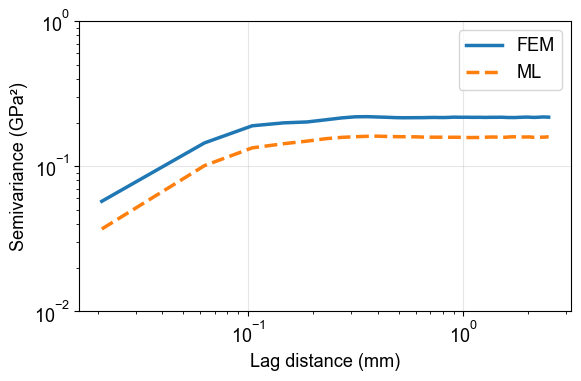

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft2, irfft2

def _radial_bin_2d(arr, n_bins=50, px_size=1.0, max_range=None):
    """Radially average a 2D array (arr[dy,dx]) into distance bins."""
    H, W = arr.shape
    cy, cx = H//2, W//2
    yy, xx = np.indices(arr.shape)
    r = np.sqrt((yy - cy)**2 + (xx - cx)**2) * px_size
    if max_range is None:
        max_range = px_size * min(H, W) / 2.0
    mask = r <= max_range
    rvals = r[mask].ravel()
    avals = arr[mask].ravel()

    edges = np.linspace(0, max_range, n_bins+1)
    mids = 0.5 * (edges[:-1] + edges[1:])
    num = np.zeros(n_bins, dtype=float)
    den = np.zeros(n_bins, dtype=float)

    idx = np.clip(np.digitize(rvals, edges) - 1, 0, n_bins-1)
    np.add.at(num, idx, avals)
    np.add.at(den, idx, 1.0)
    with np.errstate(invalid="ignore", divide="ignore"):
        prof = np.where(den > 0, num / den, np.nan)
    return mids, prof

def empirical_variogram_fft(field, px_size=1.0, n_bins=50, max_range=None):
    """
    Isotropic variogram via FFT-based autocovariance with NaN handling.
    gamma(h) = C(0) - C(h), where C is auto-covariance.
    Returns: lags (in same units as px_size), gamma(lag).
    """
    f = np.array(field, dtype=float)
    mask = np.isfinite(f).astype(float)
    f = np.where(np.isfinite(f), f, 0.0)

    # Remove mean over observed pixels
    msum = mask.sum()
    mean = (f.sum() / msum) if msum > 0 else 0.0
    fz = (f - mean) * mask

    # Autocorrelation via FFT with normalization by overlap counts
    F = rfft2(fz)
    M = rfft2(mask)
    num = irfft2(F * np.conj(F), s=f.shape)            # unnormalized auto-covariance numerator
    den = irfft2(M * np.conj(M), s=f.shape)            # number of overlapping valid pairs

    # Center the correlation map (so [cy,cx] = lag 0)
    num = np.fft.fftshift(num)
    den = np.maximum(np.fft.fftshift(den), 1e-12)      # avoid divide-by-zero

    C = num / den                                      # unbiased auto-covariance map
    C0 = C[C.shape[0]//2, C.shape[1]//2]               # C(0) = variance

    # Variogram map and radial average
    gamma_map = C0 - C
    lags, gamma = _radial_bin_2d(gamma_map, n_bins=n_bins, px_size=px_size, max_range=max_range)
    return lags, gamma

def compare_variograms(
    field_a, field_b,
    labels=("Field A","Field B"),
    px_size=1.0, n_bins=50, max_range=None,
    normalize=False, show=True
):
    """
    Compute & plot isotropic empirical variograms for two fields.
    If normalize=True, divide by each field's sill (gamma at largest lag).
    """
    la, ga = empirical_variogram_fft(field_a, px_size=px_size, n_bins=n_bins, max_range=max_range)
    lb, gb = empirical_variogram_fft(field_b, px_size=px_size, n_bins=n_bins, max_range=max_range)

    # Optional normalization to sill
    if normalize:
        sa = np.nanmax(ga); sb = np.nanmax(gb)
        ga = ga / (sa if sa and np.isfinite(sa) else 1.0)
        gb = gb / (sb if sb and np.isfinite(sb) else 1.0)
        ylab = "Normalized semivariance"
    else:
        ylab = "Semivariance (GPa²)"

    if show:
        plt.figure(figsize=(6,4))
        plt.loglog(la*0.02, ga, ms=4, lw=2.5, label=labels[0])
        plt.loglog(lb*0.02, gb, '--', ms=4, lw=2.5, label=labels[1])
        plt.xlabel("Lag distance (mm)")
        plt.ylabel(ylab)
        # plt.title("Empirical variograms (isotropic)")
        plt.grid(True, alpha=0.3)
        plt.ylim(1E-2, 1)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return (la, ga), (lb, gb)

# --- Example usage ---
# (Assuming true_map and pred_map are 2D numpy arrays of the same shape)
(la, ga), (lb, gb) = compare_variograms(stress_maps[4], pred, labels=("FEM","ML"), px_size=1.0, n_bins=60, normalize=False)

code to generate variograms for extreme cases and baseline.

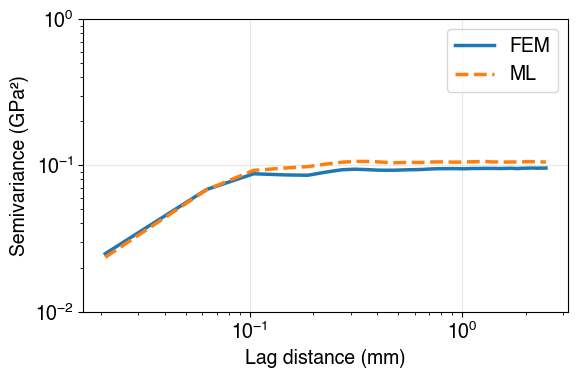

-0.9525219 0.32469133 -0.9637597243009721 0.30867135062849144


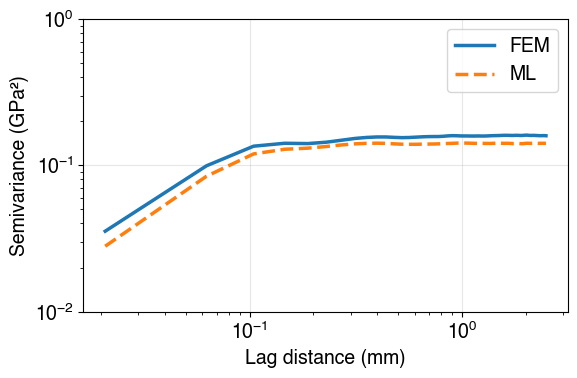

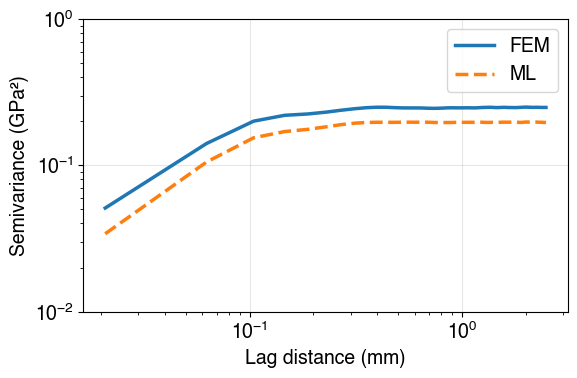

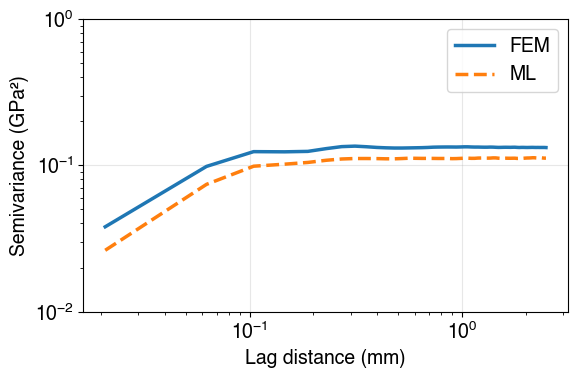

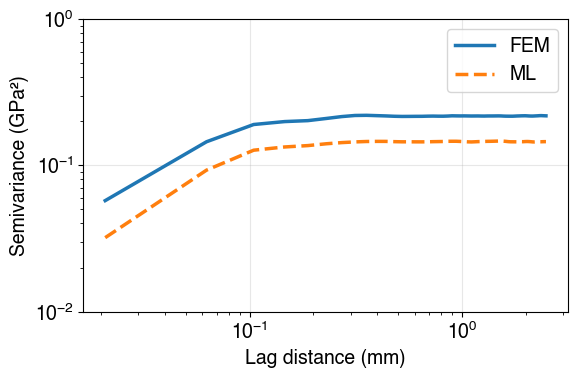

-0.8242189 0.3808839 -0.8515965211945191 0.4664009380891965


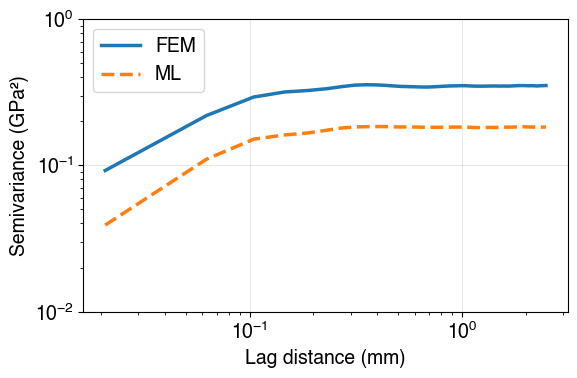

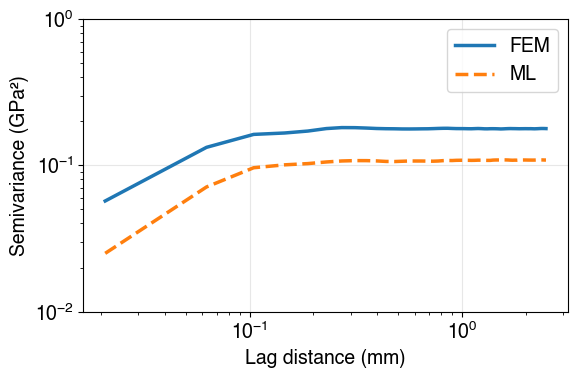

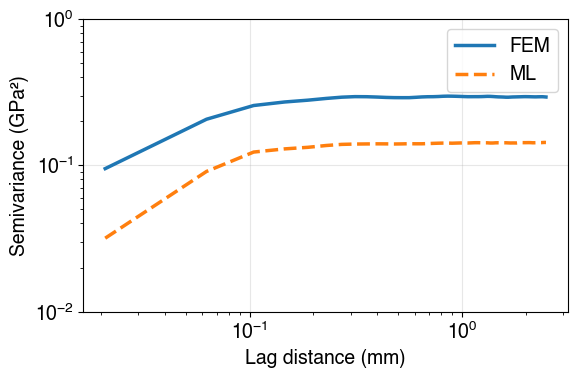

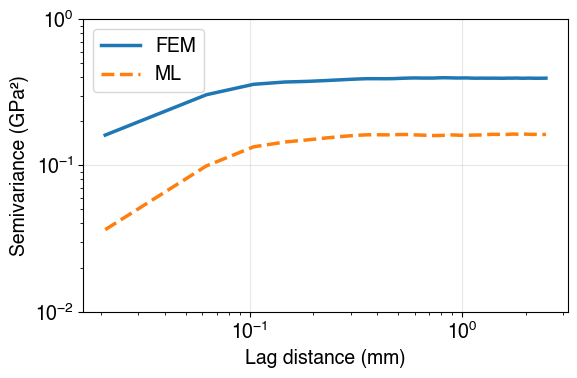

-0.62205166 0.4029209 -0.508980847307435 0.6277590612644645


In [276]:
for i in range (0, 9):
    pred = predict_full_field_center_sparse_allN(
        model,
        energy_stacks[i],
        tile_in=36, tile_out=16,
        center_size=12, stride=12,
        energy_thresh=1E-12,
        keep_one_if_empty=True,
        per_patch_norm=False,
        batch_size=256,
        pad_mode="reflect"
    )
    
    # print(np.mean(pred), np.std(pred), np.mean(stress_maps[i]), np.std(stress_maps[i]))
    (la, ga), (lb, gb) = compare_variograms(stress_maps[i], pred, labels=("FEM","ML"), px_size=1, n_bins=60, normalize=False)
    if np.any(i == np.array([0,4,8])):
        # write_thin_plate_vti(pred[3:-3, 3:-3], "field_thin_{}_ML.vti".format(i), spacing=(1.0, 1.0, 0.05), origin=(0.0, 0.0, 0.0), array_name="stress")
        # write_thin_plate_vti(stress_maps[i][3:-3, 3:-3], "field_thin_{}_FEM.vti".format(i), spacing=(1.0, 1.0, 0.05), origin=(0.0, 0.0, 0.0), array_name="stress")
        print(np.mean(pred),  np.mean(stress_maps[i]), np.mean, np.std(pred)**2, np.std(stress_maps[i])**2)


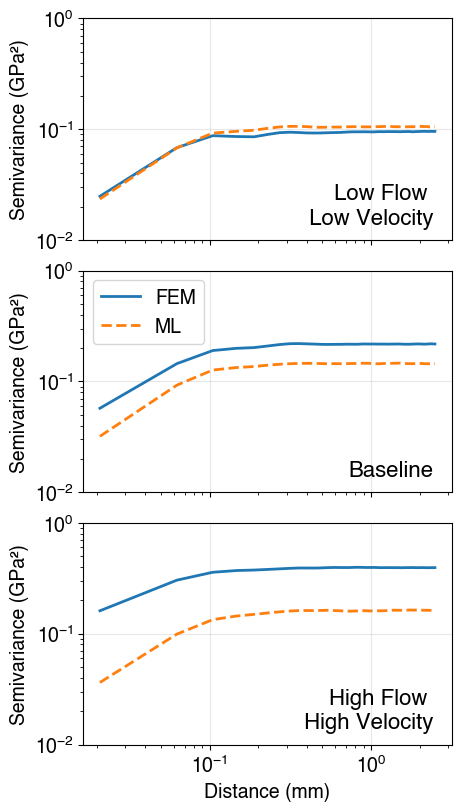

In [ ]:
# ---- Plot: 3 horizontal subplots ----
plt.rcParams.update({'font.size': 14, 'font.family': 'Helvetica'})
fig, axs = plt.subplots(3, 1, figsize=(4.5, 8), sharex=True, sharey=True, constrained_layout=True)


# FEM solid
la, ga = curves[0][0]["FEM"]
axs[0].loglog(la*0.02, ga, lw=2, label=f"FEM")
# ML dashed
lb, gb = curves[0][0]["ML"]
axs[0].loglog(lb*0.02, gb, lw=2, ls='--', label=f"ML")


axs[0].set_ylabel("Semivariance (GPa²)")

axs[0].set_ylim(1E-2, 1)

axs[0].text(0.95, 0.05, "Low Flow \n Low Velocity", transform=axs[0].transAxes, va="bottom", ha="right", fontsize=16)
axs[0].grid(alpha=0.3)

# FEM solid
la, ga = curves[1][1]["FEM"]
axs[1].loglog(la*0.02, ga, lw=2, label=f"FEM")
# ML dashed
lb, gb = curves[1][1]["ML"]
axs[1].loglog(lb*0.02, gb, lw=2, ls='--', label=f"ML")


axs[1].set_ylabel("Semivariance (GPa²)")
axs[1].legend(loc="upper left", frameon=True)

axs[1].text(0.95, 0.05, "Baseline", transform=axs[1].transAxes, va="bottom", ha="right", fontsize=16)
axs[1].grid(alpha=0.3)

# FEM solid
la, ga = curves[2][2]["FEM"]
axs[2].loglog(la*0.02, ga, lw=2, label=f"FEM")
# ML dashed
lb, gb = curves[2][2]["ML"]
axs[2].loglog(lb*0.02, gb, lw=2, ls='--', label=f"ML")


axs[2].set_ylabel("Semivariance (GPa²)")
axs[2].text(0.95, 0.05, "High Flow \n High Velocity", transform=axs[2].transAxes, va="bottom", ha="right", fontsize=16)
axs[2].set_xlabel("Distance (mm)")
axs[2].grid(alpha=0.3)

# one combined legend (avoid duplicates)
handles, labels = axs[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.savefig("variograms_3x1.png", dpi=300)
# fig.legend(by_label.values(), by_label.keys(), loc="lower", ncol=6, frameon=False)

code to calculate tensile path length:

In [396]:
import numpy as np
from collections import deque

def longest_tension_path(surfstress, *, connectivity=4, wrap=True, strictly_positive=True):
    """
    Find a long path that stays only on tension cells (stress > 0 by default).
    Uses the graph diameter (longest shortest path) within each connected component.

    Parameters
    ----------
    surfstress : 2D ndarray
        Stress field.
    connectivity : int
        4 or 8 (neighbors). 4 = up/down/left/right; 8 adds diagonals.
    wrap : bool
        If True, use toroidal wrap-around neighbors. If False, clamp to bounds.
    strictly_positive : bool
        If True, tension mask is (surfstress > 0). If False, (surfstress >= 0).

    Returns
    -------
    path_rc : list[(r, c)]
        Row/col coordinates of the chosen path from one end to the other.
    length_edges : int
        Path length counted in edges (len(path_rc) - 1).
    component_size : int
        Size (# of nodes) of the connected component that contains this path.

    Notes
    -----
    - This returns the **diameter path** of the largest-diameter tension component.
    - If you truly need the exact longest simple path, use backtracking with pruning
      on small components only (can be exponential).
    """
    H, W = surfstress.shape
    mask = (surfstress > 0) if strictly_positive else (surfstress >= 0)
    if not mask.any():
        return [], 0, 0

    # Neighbor generator
    if connectivity == 4:
        base_nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    elif connectivity == 8:
        base_nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)]
    else:
        raise ValueError("connectivity must be 4 or 8")

    def neighbors(r, c):
        for dr, dc in base_nbrs:
            rr, cc = r + dr, c + dc
            if wrap:
                rr %= H
                cc %= W
                if mask[rr, cc]:
                    yield rr, cc
            else:
                if 0 <= rr < H and 0 <= cc < W and mask[rr, cc]:
                    yield rr, cc

    # BFS utilities (on-the-fly graph)
    def bfs_from(start_r, start_c):
        """Return dist, parent, and farthest node from (start_r, start_c)."""
        dist = -np.ones((H, W), dtype=np.int32)
        parent_r = -np.ones((H, W), dtype=np.int32)
        parent_c = -np.ones((H, W), dtype=np.int32)

        q = deque()
        q.append((start_r, start_c))
        dist[start_r, start_c] = 0
        far_r, far_c = start_r, start_c

        while q:
            r, c = q.popleft()
            # Track farthest by distance
            if dist[r, c] > dist[far_r, far_c]:
                far_r, far_c = r, c
            for rr, cc in neighbors(r, c):
                if dist[rr, cc] == -1:
                    dist[rr, cc] = dist[r, c] + 1
                    parent_r[rr, cc] = r
                    parent_c[rr, cc] = c
                    q.append((rr, cc))

        return dist, (parent_r, parent_c), (far_r, far_c)

    # Find connected components of mask and compute diameter for each
    seen = np.zeros_like(mask, dtype=bool)
    best_path = []
    best_len = -1
    best_comp_size = 0

    for r0 in range(H):
        for c0 in range(W):
            if not mask[r0, c0] or seen[r0, c0]:
                continue

            # Flood-fill to collect this component's nodes
            comp_nodes = []
            q = deque([(r0, c0)])
            seen[r0, c0] = True
            while q:
                r, c = q.popleft()
                comp_nodes.append((r, c))
                for rr, cc in neighbors(r, c):
                    if not seen[rr, cc]:
                        seen[rr, cc] = True
                        q.append((rr, cc))

            comp_size = len(comp_nodes)
            if comp_size == 1:
                # Single node component => diameter 0
                if best_len < 0:  # keep at least one path
                    best_path = [comp_nodes[0]]
                    best_len = 0
                    best_comp_size = 1
                continue

            # Diameter via two BFS:
            # 1) BFS from arbitrary node to get one far end u
            sr, sc = comp_nodes[0]
            _, _, (ur, uc) = bfs_from(sr, sc)

            # 2) BFS from u to get farthest v and parents => path u..v
            dist2, (pr, pc), (vr, vc) = bfs_from(ur, uc)
            diam_len = int(dist2[vr, vc])

            # Reconstruct path u..v
            path = []
            r, c = vr, vc
            while r != -1 and c != -1:
                path.append((r, c))
                r2, c2 = pr[r, c], pc[r, c]
                r, c = int(r2), int(c2)
            path.reverse()

            # Record best by diameter (break ties by component size)
            if diam_len > best_len or (diam_len == best_len and comp_size > best_comp_size):
                best_path = path
                best_len = diam_len
                best_comp_size = comp_size

    return best_path, best_len, best_comp_size

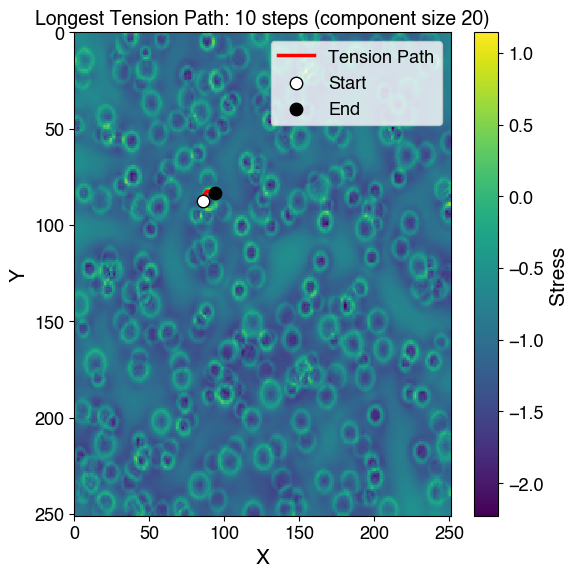

In [413]:
path, length_edges, comp_size = longest_tension_path(
    stress_maps[0],
    connectivity=8,   # use diagonals
    wrap=True,        # toroidal neighbors
    strictly_positive=True  # tension means > 0
)

plt.figure(figsize=(6,6))
plt.pcolormesh(stress_maps[0], cmap="viridis", shading="auto")
plt.colorbar(label="Stress")

# --- overlay path if found ---
if path:
    rr, cc = zip(*path)
    rr = np.array(rr)
    cc = np.array(cc)
    plt.plot(cc + 0.5, rr + 0.5, color="red", linewidth=2.5, label="Tension Path")
    plt.scatter(cc[0] + 0.5, rr[0] + 0.5, color="white", edgecolor="black", s=80, zorder=5, label="Start")
    plt.scatter(cc[-1] + 0.5, rr[-1] + 0.5, color="black", s=80, zorder=5, label="End")
    plt.legend(loc="upper right")
    plt.title(f"Longest Tension Path: {length_edges} steps (component size {comp_size})")
else:
    plt.title("No Tension Path Found")

plt.xlabel("X")
plt.ylabel("Y")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

code to calculate stress field for 1000 RVE snapshots:

In [416]:
import os, re, gc
from glob import glob
import numpy as np
from tqdm import tqdm

energy_dir   = "./out_snapshots_small_holdup"
array_key    = None
transpose_hw = True
scale_factor = 1e4

# --- extract integer index from filename like "..._snap003_E.npz"
def snap_index(path):
    m = re.search(r"_snap(\d+)_E", os.path.basename(path))
    return int(m.group(1)) if m else -1

def iter_energy_npz(energy_dir, array_key=None, transpose_hw=True):
    paths = sorted(glob(os.path.join(energy_dir, "*_E.npz")), key=snap_index)
    for p in paths:
        label = os.path.splitext(os.path.basename(p))[0].replace("_E", "")
        with np.load(p) as z:
            arr = z[array_key] if array_key else z[next(iter(z.files))]
        if transpose_hw:
            arr = arr.transpose(1, 0, 2)  # (nx, ny, T) -> (H, W, N)
        yield label, arr

# --- storage
sample_names  = []
impact_counts = []
pred_means    = []
pred_vars     = []
pred_stds     = []
path_lengths = []

for idx, (label, E) in enumerate(tqdm(iter_energy_npz(energy_dir, array_key, transpose_hw), desc="Files")):
    E = E * scale_factor

    pred = predict_full_field_center_sparse_allN(
        model,
        E,
        tile_in=36, tile_out=16,
        center_size=12, stride=12,
        energy_thresh=1e-12,
        keep_one_if_empty=True,
        per_patch_norm=False,
        batch_size=256,
        pad_mode="reflect",
    )
    path, length_edges, comp_size = longest_tension_path(
    pred,
    connectivity=8,   # use diagonals
    wrap=True,        # toroidal neighbors
    strictly_positive=True  # tension means > 0
    )

    sample_names.append(label)
    impact_counts.append(int(E.shape[-1]))
    m = float(pred.mean())
    v = float(pred.var())
    pred_means.append(m)
    pred_vars.append(v)
    pred_stds.append(float(np.sqrt(v)))
    path_lengths.append(length_edges)

    del E, pred
    gc.collect()

# turn into arrays if desired
impact_counts = np.asarray(impact_counts, int)
pred_means    = np.asarray(pred_means, float)
pred_vars     = np.asarray(pred_vars, float)
pred_stds     = np.asarray(pred_stds, float)
path_lengths  = np.asarray(path_lengths, int)

Files: 1000it [42:56,  2.58s/it]


In [417]:
impact_counts_small = impact_counts
pred_means_small    = pred_means
pred_vars_small     = pred_vars
pred_stds_small     = pred_stds
paths_small = path_lengths

In [ ]:
import os, re, gc
from glob import glob
import numpy as np
from tqdm import tqdm

energy_dir   = "./out_snapshots_large_holdup"
array_key    = None
transpose_hw = True
scale_factor = 1e4

# --- extract integer index from filename like "..._snap003_E.npz"
def snap_index(path):
    m = re.search(r"_snap(\d+)_E", os.path.basename(path))
    return int(m.group(1)) if m else -1

def iter_energy_npz(energy_dir, array_key=None, transpose_hw=True):
    paths = sorted(glob(os.path.join(energy_dir, "*_E.npz")), key=snap_index)
    for p in paths:
        label = os.path.splitext(os.path.basename(p))[0].replace("_E", "")
        with np.load(p) as z:
            arr = z[array_key] if array_key else z[next(iter(z.files))]
        if transpose_hw:
            arr = arr.transpose(1, 0, 2)  # (nx, ny, T) -> (H, W, N)
        yield label, arr

# --- storage
sample_names  = []
impact_counts = []
pred_means    = []
pred_vars     = []
pred_stds     = []
path_lengths = []

for idx, (label, E) in enumerate(tqdm(iter_energy_npz(energy_dir, array_key, transpose_hw), desc="Files")):
    E = E * scale_factor

    pred = predict_full_field_center_sparse_allN(
        model,
        E,
        tile_in=36, tile_out=16,
        center_size=12, stride=12,
        energy_thresh=1e-12,
        keep_one_if_empty=True,
        per_patch_norm=False,
        batch_size=256,
        pad_mode="reflect",
    )
    path, length_edges, comp_size = longest_tension_path(
    pred,
    connectivity=8,   # use diagonals
    wrap=True,        # toroidal neighbors
    strictly_positive=True  # tension means > 0
    )

    sample_names.append(label)
    impact_counts.append(int(E.shape[-1]))
    m = float(pred.mean())
    v = float(pred.var())
    pred_means.append(m)
    pred_vars.append(v)
    pred_stds.append(float(np.sqrt(v)))
    path_lengths.append(length_edges)

    del E, pred
    gc.collect()

# turn into arrays if desired
impact_counts = np.asarray(impact_counts, int)
pred_means    = np.asarray(pred_means, float)
pred_vars     = np.asarray(pred_vars, float)
pred_stds     = np.asarray(pred_stds, float)
path_lengths  = np.asarray(path_lengths, int)

In [ ]:
impact_counts_large = impact_counts
pred_means_large    = pred_means
pred_vars_large     = pred_vars
pred_stds_large     = pred_stds
paths_large = path_lengths

compare process strategies:

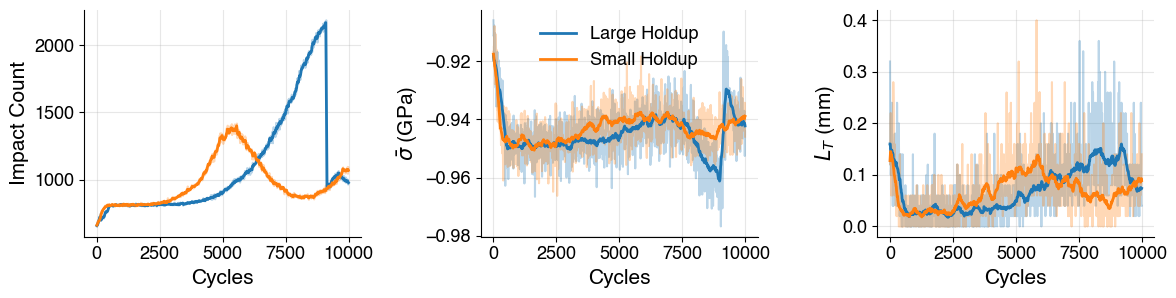

In [430]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "Helvetica",   # or "Arial" if Helvetica not installed
    "font.size": 14,              # base font
    "axes.labelsize": 15,         # axis labels
    "xtick.labelsize": 13,        # tick labels
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

def moving_avg(y, window=25):
    return pd.Series(y).rolling(window, center=True, min_periods=1).mean().to_numpy()

# --- Data prep ---
x = 10 * np.arange(len(pred_means_large))

# 1) Means
y_large_means = np.flip(pred_means_large)
y_small_means = np.flip(pred_means_small)
y_large_means_s = moving_avg(y_large_means)
y_small_means_s = moving_avg(y_small_means)

# 2) Impact counts
y_large_counts = np.flip(impact_counts_large)
y_small_counts = np.flip(impact_counts_small)
y_large_counts_s = moving_avg(y_large_counts, 5)
y_small_counts_s = moving_avg(y_small_counts, 5)

# 3) Ratio std/mean
y_large_ratio = np.flip(paths_large)*0.02
y_small_ratio = np.flip(paths_small)*0.02
y_large_ratio_s = moving_avg(y_large_ratio)
y_small_ratio_s = moving_avg(y_small_ratio)

# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=False)

# Panel 1: Impact Count
axes[0].plot(x, y_large_counts, color="C0", alpha=0.3)
axes[0].plot(x, y_small_counts, color="C1", alpha=0.3)
axes[0].plot(x, y_large_counts_s, color="C0", linewidth=2)
axes[0].plot(x, y_small_counts_s, color="C1", linewidth=2)
axes[0].set_xlabel("Cycles")
axes[0].set_ylabel("Impact Count")
# axes[0].set_title("Impact Count")

# Panel 2: RSD
axes[2].plot(x, y_large_ratio, color="C0", alpha=0.3)
axes[2].plot(x, y_small_ratio, color="C1", alpha=0.3)
axes[2].plot(x, y_large_ratio_s, color="C0", linewidth=2, label="Large Holdup")
axes[2].plot(x, y_small_ratio_s, color="C1", linewidth=2, label="Small Holdup")
axes[2].set_xlabel("Cycles")
axes[2].set_ylabel(r"$L_T$ (mm)")
# axes[1].set_yscale('log')
# axes[1].set_title("Relative Std. Dev.")

# Panel 3: Mean Stress
axes[1].plot(x, y_large_means, color="C0", alpha=0.3)
axes[1].plot(x, y_small_means, color="C1", alpha=0.3)
axes[1].plot(x, y_large_means_s, color="C0", linewidth=2, label ="Large Holdup")
axes[1].plot(x, y_small_means_s, color="C1", linewidth=2, label ="Small Holdup")
axes[1].set_xlabel("Cycles")
axes[1].set_ylabel(r"$\bar{\sigma}$ (GPa)")
# axes[2].set_title("Mean Surface Stress")
axes[1].legend(frameon=False)


for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.subplots_adjust(wspace=0.35)  # add horizontal space between panels

plt.tight_layout()
plt.savefig("summary_plots_wide.jpg", dpi=300, bbox_inches="tight")
plt.show()